## 1. Install dependencies

In [1]:
%pip install -q huggingface_hub scikit-learn scipy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Imports, reproducibility, and paths

In [2]:
import os
import json
import time
import random
import pickle
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

WORK_DIR = Path("/kaggle/working")
DATA_DIR = WORK_DIR / "cmu_mosi_data"
RESULTS_DIR = WORK_DIR / "cmu_mosi_results"
CHECKPOINT_DIR = WORK_DIR / "cmu_mosi_checkpoints"

for directory in [DATA_DIR, RESULTS_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PKL_PATH = DATA_DIR / "Processed" / "aligned_50.pkl"
CHECKPOINT_PATH = CHECKPOINT_DIR / "cmu_mosi_baseline_best.pth"

print("Data path:", PKL_PATH)
print("Results path:", RESULTS_DIR)

Python: 3.13.15
PyTorch: 2.11.0+cu128
Device: cuda
Data path: /kaggle/working/cmu_mosi_data/Processed/aligned_50.pkl
Results path: /kaggle/working/cmu_mosi_results


## 3. Download the aligned CMU-MOSI file

In [3]:
from huggingface_hub import hf_hub_download

REPO_ID = "tamb2203579/CMU-MOSI"
REPO_TYPE = "dataset"
REMOTE_FILENAME = "Processed/aligned_50.pkl"

if PKL_PATH.exists() and PKL_PATH.stat().st_size > 1_000_000:
    print("Using existing file:", PKL_PATH)
else:
    downloaded_path = hf_hub_download(
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        filename=REMOTE_FILENAME,
        local_dir=str(DATA_DIR),
    )
    downloaded_path = Path(downloaded_path)
    PKL_PATH.parent.mkdir(parents=True, exist_ok=True)
    if downloaded_path.resolve() != PKL_PATH.resolve():
        shutil.copy2(downloaded_path, PKL_PATH)

if not PKL_PATH.exists() or PKL_PATH.stat().st_size < 1_000_000:
    raise RuntimeError(
        "Dataset file was not downloaded correctly. Check Kaggle internet access "
        "and the Hugging Face dataset file path."
    )

print("Downloaded file:", PKL_PATH)
print("File size (MB):", round(PKL_PATH.stat().st_size / (1024**2), 2))

Processed/aligned_50.pkl: reconstructing file:   0%|          |  0.00B /  367MB            

Processed/aligned_50.pkl: downloading bytes:           |  0.00B            

Downloaded file: /kaggle/working/cmu_mosi_data/Processed/aligned_50.pkl
File size (MB): 350.24


## 4. Load and inspect the dataset

In [4]:
# Only unpickle files from a source you trust.
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

required_splits = {"train", "valid", "test"}
required_keys = {
    "text", "audio", "vision", "classification_labels",
    "regression_labels", "id"
}

if not isinstance(data, dict) or not required_splits.issubset(data):
    raise ValueError(
        f"Unexpected dataset structure. Expected splits {required_splits}; "
        f"got {list(data.keys()) if isinstance(data, dict) else type(data)}"
    )

for split_name in ["train", "valid", "test"]:
    split = data[split_name]
    missing = required_keys - set(split.keys())
    if missing:
        raise ValueError(f"{split_name} split is missing keys: {sorted(missing)}")
    print(f"\n--- {split_name.upper()} ---")
    for key in ["text", "audio", "vision", "classification_labels", "regression_labels", "id"]:
        arr = np.asarray(split[key])
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


--- TRAIN ---
text: shape=(1284, 50, 768), dtype=float32
audio: shape=(1284, 50, 5), dtype=float64
vision: shape=(1284, 50, 20), dtype=float64
classification_labels: shape=(1284,), dtype=float64
regression_labels: shape=(1284,), dtype=float64
id: shape=(1284,), dtype=<U16

--- VALID ---
text: shape=(229, 50, 768), dtype=float32
audio: shape=(229, 50, 5), dtype=float64
vision: shape=(229, 50, 20), dtype=float64
classification_labels: shape=(229,), dtype=float64
regression_labels: shape=(229,), dtype=float64
id: shape=(229,), dtype=<U16

--- TEST ---
text: shape=(686, 50, 768), dtype=float32
audio: shape=(686, 50, 5), dtype=float64
vision: shape=(686, 50, 20), dtype=float64
classification_labels: shape=(686,), dtype=float64
regression_labels: shape=(686,), dtype=float64
id: shape=(686,), dtype=<U16


## 5. Validate labels and feature shapes

In [5]:
MODALITIES = ["text", "audio", "vision"]
SPLITS = ["train", "valid", "test"]

# Use the provided classification labels as a three-class target.
y = {}
raw_features = {m: {} for m in MODALITIES}
sample_ids = {}

for split_name in SPLITS:
    split = data[split_name]
    labels = np.asarray(split["classification_labels"]).reshape(-1)

    if not np.all(np.isfinite(labels)):
        raise ValueError(f"Non-finite classification labels in {split_name}.")
    if not np.allclose(labels, np.round(labels)):
        raise ValueError(f"Classification labels are not integer-coded in {split_name}.")

    labels = labels.astype(np.int64)
    classes = np.unique(labels)
    if not set(classes.tolist()).issubset({0, 1, 2}):
        raise ValueError(
            f"Expected labels in {{0,1,2}}; found {classes.tolist()} in {split_name}."
        )
    y[split_name] = labels
    sample_ids[split_name] = np.asarray(split["id"]).reshape(-1)

    for modality in MODALITIES:
        arr = np.asarray(split[modality], dtype=np.float32)
        if arr.ndim != 3:
            raise ValueError(
                f"{split_name}/{modality} expected [samples, time, features], got {arr.shape}"
            )
        if arr.shape[0] != len(labels):
            raise ValueError(f"Sample count mismatch for {split_name}/{modality}.")
        if not np.isfinite(arr).all():
            raise ValueError(f"Non-finite values in {split_name}/{modality}.")
        raw_features[modality][split_name] = arr

    print(
        f"{split_name}: n={len(labels)}, "
        f"label counts={pd.Series(labels).value_counts().sort_index().to_dict()}"
    )

print("\nAll basic data checks passed.")

train: n=1284, label counts={0: 552, 1: 53, 2: 679}
valid: n=229, label counts={0: 92, 1: 13, 2: 124}
test: n=686, label counts={0: 379, 1: 30, 2: 277}

All basic data checks passed.


## 6. Mean-pool sequences and normalize

In [6]:
# The aligned file has 50 time steps per sample. Mean-pooling creates one vector
# per modality and sample. Fit each scaler on TRAIN only to avoid leakage.
X = {m: {} for m in MODALITIES}
scalers = {}

for modality in MODALITIES:
    for split_name in SPLITS:
        X[modality][split_name] = raw_features[modality][split_name].mean(axis=1)

    scaler = StandardScaler()
    scaler.fit(X[modality]["train"])
    scalers[modality] = scaler

    for split_name in SPLITS:
        X[modality][split_name] = scaler.transform(
            X[modality][split_name]
        ).astype(np.float32)

INPUT_DIMS = {m: X[m]["train"].shape[1] for m in MODALITIES}
print("Pooled feature dimensions:", INPUT_DIMS)

for split_name in SPLITS:
    print(
        split_name,
        {m: X[m][split_name].shape for m in MODALITIES},
        "labels:", y[split_name].shape
    )

Pooled feature dimensions: {'text': 768, 'audio': 5, 'vision': 20}
train {'text': (1284, 768), 'audio': (1284, 5), 'vision': (1284, 20)} labels: (1284,)
valid {'text': (229, 768), 'audio': (229, 5), 'vision': (229, 20)} labels: (229,)
test {'text': (686, 768), 'audio': (686, 5), 'vision': (686, 20)} labels: (686,)


## 7. Create data loaders

In [7]:
BATCH_SIZE = 64

def make_loader(split_name, shuffle=False):
    tensors = [
        torch.from_numpy(X[m][split_name]).float()
        for m in MODALITIES
    ]
    labels = torch.from_numpy(y[split_name]).long()
    dataset = TensorDataset(*tensors, labels)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )

train_loader = make_loader("train", shuffle=True)
valid_loader = make_loader("valid")
test_loader = make_loader("test")

print("Batches:", {
    "train": len(train_loader),
    "valid": len(valid_loader),
    "test": len(test_loader),
})

Batches: {'train': 21, 'valid': 4, 'test': 11}


## 8. Define the trimodal baseline

In [8]:
class MultimodalBaseline(nn.Module):
    def __init__(self, input_dims, hidden_dim=128, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoders = nn.ModuleDict({
            m: nn.Sequential(
                nn.Linear(input_dims[m], hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            for m in MODALITIES
        })
        self.modality_heads = nn.ModuleDict({
            m: nn.Linear(hidden_dim, num_classes)
            for m in MODALITIES
        })
        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_dim * len(MODALITIES), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, inputs):
        embeddings = {
            m: self.encoders[m](inputs[m])
            for m in MODALITIES
        }
        modality_logits = {
            m: self.modality_heads[m](embeddings[m])
            for m in MODALITIES
        }
        fused_logits = self.fusion_head(
            torch.cat([embeddings[m] for m in MODALITIES], dim=1)
        )
        return fused_logits, modality_logits

model = MultimodalBaseline(INPUT_DIMS).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

MultimodalBaseline(
  (encoders): ModuleDict(
    (text): Sequential(
      (0): Linear(in_features=768, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (audio): Sequential(
      (0): Linear(in_features=5, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (vision): Sequential(
      (0): Linear(in_features=20, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
  )
  (modality_heads): ModuleDict(
    (text): Linear(in_features=128, out_features=3, bias=True)
    (audio): Linear(in_features=128, out_features=3, bias=True)
    (vision): Linear(in_features=128, out_features=3, bias=True)
  )
  (fusion_head): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)
Trainable parameters: 152716


## 9. Training and validation

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

MAX_EPOCHS = 40
PATIENCE = 6
AUXILIARY_LOSS_WEIGHT = 0.3

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
history = []

def evaluate_loader(model, loader):
    model.eval()
    all_labels, all_predictions = [], []
    with torch.no_grad():
        for batch in loader:
            *feature_tensors, labels = batch
            inputs = {
                m: feature_tensors[i].to(DEVICE, non_blocking=True)
                for i, m in enumerate(MODALITIES)
            }
            logits, _ = model(inputs)
            predictions = logits.argmax(dim=1).cpu().numpy()
            all_predictions.extend(predictions.tolist())
            all_labels.extend(labels.numpy().tolist())

    return {
        "accuracy": float(accuracy_score(all_labels, all_predictions)),
        "macro_f1": float(f1_score(
            all_labels, all_predictions,
            labels=[0, 1, 2], average="macro", zero_division=0
        )),
    }

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        *feature_tensors, labels = batch
        inputs = {
            m: feature_tensors[i].to(DEVICE, non_blocking=True)
            for i, m in enumerate(MODALITIES)
        }
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        fused_logits, modality_logits = model(inputs)

        fused_loss = criterion(fused_logits, labels)
        aux_loss = sum(
            criterion(modality_logits[m], labels)
            for m in MODALITIES
        ) / len(MODALITIES)

        loss = fused_loss + AUXILIARY_LOSS_WEIGHT * aux_loss
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    val_metrics = evaluate_loader(model, valid_loader)
    epoch_row = {
        "epoch": epoch,
        "train_loss": total_loss / max(n_batches, 1),
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }
    history.append(epoch_row)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"loss={epoch_row['train_loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if not CHECKPOINT_PATH.exists():
    raise RuntimeError("No checkpoint was saved; training did not complete successfully.")

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

# Load the checkpoint with compatibility for PyTorch versions.
try:
    state = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
except TypeError:
    state = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(state)

print("Best epoch:", best_epoch)
print("Best validation macro-F1:", round(best_val_f1, 4))
print("Checkpoint:", CHECKPOINT_PATH)

Epoch 01/40 | loss=1.0703 | val_acc=0.7031 | val_macro_f1=0.4798
Epoch 02/40 | loss=0.7987 | val_acc=0.7511 | val_macro_f1=0.5139
Epoch 03/40 | loss=0.7056 | val_acc=0.7729 | val_macro_f1=0.5270
Epoch 04/40 | loss=0.6018 | val_acc=0.7467 | val_macro_f1=0.5090
Epoch 05/40 | loss=0.5343 | val_acc=0.7380 | val_macro_f1=0.5029
Epoch 06/40 | loss=0.4690 | val_acc=0.7467 | val_macro_f1=0.5053
Epoch 07/40 | loss=0.3987 | val_acc=0.7642 | val_macro_f1=0.5218
Epoch 08/40 | loss=0.3266 | val_acc=0.7642 | val_macro_f1=0.5202
Epoch 09/40 | loss=0.2765 | val_acc=0.7424 | val_macro_f1=0.5028
Early stopping at epoch 9.
Best epoch: 3
Best validation macro-F1: 0.527
Checkpoint: /kaggle/working/cmu_mosi_checkpoints/cmu_mosi_baseline_best.pth


## 10. Plot training history

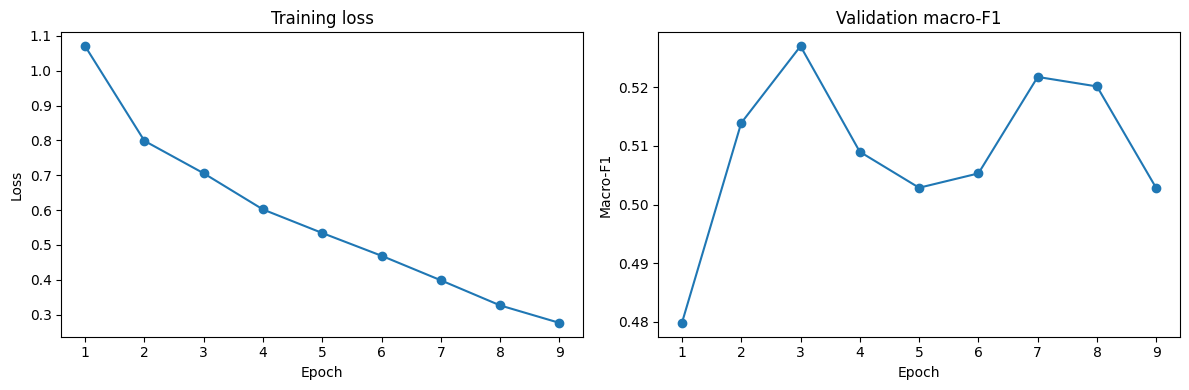

Saved: /kaggle/working/cmu_mosi_results/training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], marker="o")
axes[1].set_title("Validation macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")

plt.tight_layout()
plot_path = RESULTS_DIR / "training_curves.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

## 11. Test-set evaluation

Test accuracy: 0.7551
Test macro-F1: 0.5131

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       379
           1       0.00      0.00      0.00        30
           2       0.69      0.81      0.75       277

    accuracy                           0.76       686
   macro avg       0.50      0.53      0.51       686
weighted avg       0.73      0.76      0.74       686



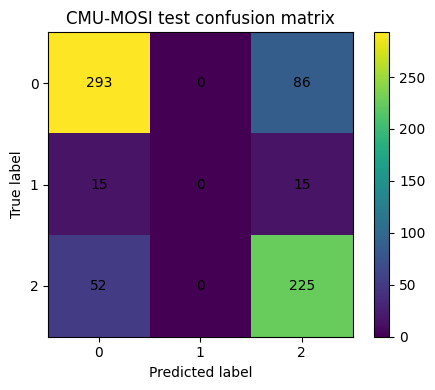

Saved metrics and confusion matrix to: /kaggle/working/cmu_mosi_results


In [11]:
# Evaluate the selected checkpoint on the test set once.
test_metrics = evaluate_loader(model, test_loader)

model.eval()
test_labels, test_predictions = [], []
test_fused_probabilities = []
test_modality_probabilities = {m: [] for m in MODALITIES}

with torch.no_grad():
    for batch in test_loader:
        *feature_tensors, labels = batch
        inputs = {
            m: feature_tensors[i].to(DEVICE, non_blocking=True)
            for i, m in enumerate(MODALITIES)
        }
        fused_logits, modality_logits = model(inputs)

        test_labels.extend(labels.numpy().tolist())
        test_predictions.extend(fused_logits.argmax(dim=1).cpu().numpy().tolist())
        test_fused_probabilities.extend(
            torch.softmax(fused_logits, dim=1).cpu().numpy().tolist()
        )

        for m in MODALITIES:
            test_modality_probabilities[m].extend(
                torch.softmax(modality_logits[m], dim=1).cpu().numpy().tolist()
            )

print("Test accuracy:", round(test_metrics["accuracy"], 4))
print("Test macro-F1:", round(test_metrics["macro_f1"], 4))
print("\nClassification report:")
report = classification_report(
    test_labels, test_predictions,
    labels=[0, 1, 2], zero_division=0, output_dict=True
)
print(classification_report(
    test_labels, test_predictions,
    labels=[0, 1, 2], zero_division=0
))

cm = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title("CMU-MOSI test confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
cm_path = RESULTS_DIR / "test_confusion_matrix.png"
plt.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "baseline_metrics.json", "w") as f:
    json.dump({
        "dataset": "CMU-MOSI",
        "source": f"{REPO_ID}/{REMOTE_FILENAME}",
        "seed": SEED,
        "best_epoch": int(best_epoch),
        "best_validation_macro_f1": float(best_val_f1),
        "test_accuracy": float(test_metrics["accuracy"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "input_dimensions": INPUT_DIMS,
        "test_classification_report": report,
    }, f, indent=2)

print("Saved metrics and confusion matrix to:", RESULTS_DIR)

## 12. Calculate per-sample Modality Bias Scores (MBS)

Operational definition used here: for each test sample, obtain each modality head's softmax probability assigned to the **true class**, then normalize the three probabilities so their per-sample scores sum to 1.

\[
MBS_m^{(i)} =
\frac{p_m(y_i\mid x_m^{(i)})}
{\sum_{k\in\{T,A,V\}} p_k(y_i\mid x_k^{(i)})}
\]

The balanced reference is 1/3 per modality. This is a **relative true-class confidence score**, not a causal measure of modality importance. Compare it later with modality ablation and XAI attributions. Report the exact definition when presenting results.

In [12]:
from scipy.special import softmax

true_labels_np = np.asarray(test_labels, dtype=np.int64)
prob_arrays = {
    m: np.asarray(test_modality_probabilities[m], dtype=np.float64)
    for m in MODALITIES
}

if any(prob_arrays[m].shape != (len(true_labels_np), 3) for m in MODALITIES):
    raise ValueError("Unexpected modality probability array shape.")

mbs_rows = []
test_ids = sample_ids["test"]

for i, true_label in enumerate(true_labels_np):
    row = {
        "sample_index": int(i),
        "sample_id": str(test_ids[i]),
        "true_label": int(true_label),
        "fused_prediction": int(test_predictions[i]),
        "fused_correct": bool(test_predictions[i] == true_label),
    }

    true_class_probs = {}
    for m in MODALITIES:
        p = float(prob_arrays[m][i, true_label])
        true_class_probs[m] = p
        row[f"{m}_true_class_prob"] = p

    denom = sum(true_class_probs.values())
    if not np.isfinite(denom) or denom <= 0:
        raise ValueError(f"Invalid MBS denominator at test sample {i}.")

    for m in MODALITIES:
        row[f"{m}_MBS"] = true_class_probs[m] / denom

    mbs_rows.append(row)

mbs_df = pd.DataFrame(mbs_rows)
mbs_columns = [f"{m}_MBS" for m in MODALITIES]

# Verify the scores sum to 1 for every sample.
row_sums = mbs_df[mbs_columns].sum(axis=1).to_numpy()
assert np.allclose(row_sums, 1.0, atol=1e-6)

mbs_csv_path = RESULTS_DIR / "cmu_mosi_test_mbs.csv"
mbs_df.to_csv(mbs_csv_path, index=False)

summary = mbs_df[mbs_columns].agg(["mean", "std", "median", "min", "max"]).T
summary["balanced_reference"] = 1.0 / 3.0
summary.to_csv(RESULTS_DIR / "cmu_mosi_mbs_summary.csv")

print("Mean MBS by modality:")
print(mbs_df[mbs_columns].mean().round(4))
print("\nMBS summary:")
display(summary.round(4))
print("\nFirst five samples:")
display(mbs_df.head())
print("Saved per-sample scores:", mbs_csv_path)

Mean MBS by modality:
text_MBS      0.4059
audio_MBS     0.3001
vision_MBS    0.2940
dtype: float64

MBS summary:


,mean,std,median,min,max,balanced_reference
text_MBS,0.4059,0.1266,0.4406,0.0079,0.6041,0.3333
audio_MBS,0.3001,0.0686,0.2829,0.0641,0.7875,0.3333
vision_MBS,0.2940,0.0769,0.2776,0.1117,0.6322,0.3333



First five samples:


,sample_index,sample_id,true_label,fused_prediction,fused_correct,text_true_class_prob,audio_true_class_prob,vision_true_class_prob,text_MBS,audio_MBS,vision_MBS
0,0,c7UH_rxdZv4$_$24,0,0,True,0.777037,0.348871,0.370848,0.519147,0.233085,0.247768
1,1,c7UH_rxdZv4$_$25,1,2,False,0.002465,0.054769,0.090111,0.016727,0.371707,0.611566
2,2,c7UH_rxdZv4$_$26,0,0,True,0.491454,0.417280,0.349459,0.390603,0.331650,0.277747
3,3,c7UH_rxdZv4$_$27,0,0,True,0.741568,0.460850,0.480108,0.440747,0.273904,0.285349
4,4,c7UH_rxdZv4$_$20,0,0,True,0.962763,0.560271,0.460398,0.485403,0.282476,0.232122


Saved per-sample scores: /kaggle/working/cmu_mosi_results/cmu_mosi_test_mbs.csv


## 13. Visualize mean MBS

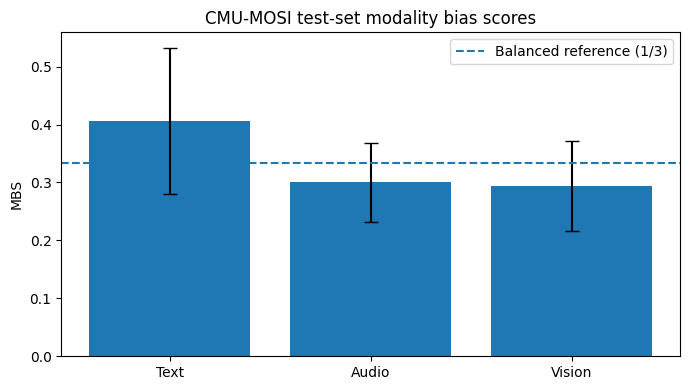

Saved: /kaggle/working/cmu_mosi_results/cmu_mosi_mean_mbs.png


In [13]:
mean_mbs = mbs_df[mbs_columns].mean()
std_mbs = mbs_df[mbs_columns].std()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Text", "Audio", "Vision"], mean_mbs.values, yerr=std_mbs.values, capsize=5)
ax.axhline(1/3, linestyle="--", label="Balanced reference (1/3)")
ax.set_ylabel("MBS")
ax.set_title("CMU-MOSI test-set modality bias scores")
ax.legend()
plt.tight_layout()

mbs_plot_path = RESULTS_DIR / "cmu_mosi_mean_mbs.png"
plt.savefig(mbs_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", mbs_plot_path)

## 14. Save run manifest

In [14]:
manifest = {
    "dataset": "CMU-MOSI",
    "dataset_source": f"{REPO_ID}/{REMOTE_FILENAME}",
    "feature_method": "mean pooling over 50 aligned time steps",
    "normalization": "StandardScaler fit on training split only",
    "labels": "classification_labels (three classes: 0, 1, 2)",
    "modalities": MODALITIES,
    "input_dimensions": INPUT_DIMS,
    "seed": SEED,
    "best_epoch": int(best_epoch),
    "best_validation_macro_f1": float(best_val_f1),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "mbs_definition": (
        "Each modality head's probability for the true class, normalized "
        "across text/audio/vision per sample."
    ),
    "outputs": sorted(p.name for p in RESULTS_DIR.iterdir() if p.is_file()),
}
with open(RESULTS_DIR / "run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("\nFinal result files:")
for path in sorted(RESULTS_DIR.iterdir()):
    if path.is_file():
        print(f"{path.name:35s} {path.stat().st_size / 1024:.1f} KB")

{
  "dataset": "CMU-MOSI",
  "dataset_source": "tamb2203579/CMU-MOSI/Processed/aligned_50.pkl",
  "feature_method": "mean pooling over 50 aligned time steps",
  "normalization": "StandardScaler fit on training split only",
  "labels": "classification_labels (three classes: 0, 1, 2)",
  "modalities": [
    "text",
    "audio",
    "vision"
  ],
  "input_dimensions": {
    "text": 768,
    "audio": 5,
    "vision": 20
  },
  "seed": 42,
  "best_epoch": 3,
  "best_validation_macro_f1": 0.5270212383755476,
  "test_accuracy": 0.7551020408163265,
  "test_macro_f1": 0.5130773736190496,
  "mbs_definition": "Each modality head's probability for the true class, normalized across text/audio/vision per sample.",
  "outputs": [
    "baseline_metrics.json",
    "cmu_mosi_mbs_summary.csv",
    "cmu_mosi_mean_mbs.png",
    "cmu_mosi_test_mbs.csv",
    "test_confusion_matrix.png",
    "training_curves.png",
    "training_history.csv"
  ]
}

Final result files:
baseline_metrics.json               1.1 KB

In [16]:
GITHUB_REPO = "Vaishnavi23457/DL_project"
GITHUB_BRANCH = "main"

try:
    from kaggle_secrets import UserSecretsClient
    TOKEN = UserSecretsClient().get_secret("GH_TOKEN")
except Exception:
    TOKEN = os.environ.get("GH_TOKEN")

if not TOKEN:
    print("GH_TOKEN not found. Push skipped.")
else:
    import base64

    repo_dir = WORK_DIR / "DL_project_cmu_mosi_push"

    if not (repo_dir / ".git").is_dir():
        if repo_dir.exists():
            shutil.rmtree(repo_dir)

        subprocess.run(
            [
                "git", "clone", "--branch", GITHUB_BRANCH,
                f"https://github.com/{GITHUB_REPO}.git", str(repo_dir)
            ],
            check=True,
        )

    target_results = repo_dir / "modality_bias/results/cmu_mosi"
    target_checkpoints = repo_dir / "modality_bias/checkpoints"

    target_results.mkdir(parents=True, exist_ok=True)
    target_checkpoints.mkdir(parents=True, exist_ok=True)

    for file in RESULTS_DIR.iterdir():
        if file.is_file():
            shutil.copy2(file, target_results / file.name)

    shutil.copy2(
        CHECKPOINT_PATH,
        target_checkpoints / "cmu_mosi_baseline_best.pth"
    )

    subprocess.run(
        ["git", "-C", str(repo_dir), "config", "user.name", "Kaggle Notebook"],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(repo_dir), "config", "user.email",
         "kaggle-notebook@users.noreply.github.com"],
        check=True,
    )

    # IMPORTANT: use two separate git add commands.
    subprocess.run(
        ["git", "-C", str(repo_dir), "add", "modality_bias/results/cmu_mosi"],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(repo_dir), "add", "-f",
         "modality_bias/checkpoints/cmu_mosi_baseline_best.pth"],
        check=True,
    )

    status = subprocess.run(
        ["git", "-C", str(repo_dir), "status", "--porcelain"],
        capture_output=True, text=True, check=True
    ).stdout.strip()

    if not status:
        print("No new changes to push.")
    else:
        auth = "AUTHORIZATION: basic " + base64.b64encode(
            f"x-access-token:{TOKEN}".encode()
        ).decode()

        subprocess.run(
            ["git", "-C", str(repo_dir),
             "-c", f"http.extraheader={auth}",
             "commit", "-m", "Add CMU-MOSI baseline and MBS results"],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(repo_dir),
             "-c", f"http.extraheader={auth}",
             "push", "origin", GITHUB_BRANCH],
            check=True,
        )

        print("CMU-MOSI results and checkpoint pushed successfully.")

[main eb2078d] Add CMU-MOSI baseline and MBS results
 9 files changed, 780 insertions(+)
 create mode 100644 modality_bias/checkpoints/cmu_mosi_baseline_best.pth
 create mode 100644 modality_bias/results/cmu_mosi/baseline_metrics.json
 create mode 100644 modality_bias/results/cmu_mosi/cmu_mosi_mbs_summary.csv
 create mode 100644 modality_bias/results/cmu_mosi/cmu_mosi_mean_mbs.png
 create mode 100644 modality_bias/results/cmu_mosi/cmu_mosi_test_mbs.csv
 create mode 100644 modality_bias/results/cmu_mosi/run_manifest.json
 create mode 100644 modality_bias/results/cmu_mosi/test_confusion_matrix.png
 create mode 100644 modality_bias/results/cmu_mosi/training_curves.png
 create mode 100644 modality_bias/results/cmu_mosi/training_history.csv
CMU-MOSI results and checkpoint pushed successfully.


To https://github.com/Vaishnavi23457/DL_project.git
   d164493..eb2078d  main -> main
